# Hyperparameter Tuning EDA

Deep-dive exploration of the Optuna tuning study, including:
- Trial history and optimization trajectory
- Hyperparameter importance and interactions
- Parameter distributions and marginal effects
- Visualization of the strict spatiotemporal train/test split
- 3-fold spatial cross-validation fold analysis (used during tuning)

**Pipeline design:** train and test are disjoint in **both station ID and year**:
- Train: 21 stations, 1980–2016
- Test: 5 stations (`aasu_UH`, `afono_UH`, `aunuu_UH`, `poloa_UH`, `vaipito_UH`), 2017–2024
- Tuning: 3-fold spatial CV over the 21 train stations
- Final training: full LOSO CV over the 21 train stations

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
from pathlib import Path
import json
import sqlite3
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print('optuna not installed; some plots will use raw SQL instead')

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.facecolor': 'white',
})

TUNING_DIR = Path('../output/tuning/weekly_land')
DB_PATH = TUNING_DIR / 'study.db'
BEST_PATH = TUNING_DIR / 'best.json'
TRIALS_PATH = TUNING_DIR / 'trials.csv'
DATASET_PATH = Path('../data/weekly_dataset.npz')

# Load trials CSV
trials_df = pd.read_csv(TRIALS_PATH)
print(f'Loaded {len(trials_df)} trials')
trials_df.head()

Loaded 60 trials


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_climate_multiplier,params_dem_units,params_dropout,params_hidden_units,params_learning_rate,params_month_units,params_weight_decay,state
0,0,27.838274,2026-09-24 13:14:48.655333,2026-09-24 13:16:15.517581,0 days 00:01:26.862248,512,7,128,0.1,320,0.001050,48,0.000133,COMPLETE
1,1,30.360898,2026-09-24 13:16:15.543300,2026-09-24 13:19:05.167847,0 days 00:02:49.624547,512,2,128,0.1,128,0.000542,64,0.000007,COMPLETE
2,2,27.934542,2026-09-24 13:19:05.190334,2026-09-24 13:21:54.543144,0 days 00:02:49.352810,128,11,32,0.3,192,0.001015,32,0.000001,COMPLETE
3,3,27.492031,2026-09-24 13:21:54.583204,2026-09-24 13:24:46.389006,0 days 00:02:51.805802,128,11,32,0.5,512,0.001454,16,0.000021,COMPLETE
4,4,28.517607,2026-09-24 13:24:46.415293,2026-09-24 13:28:11.703726,0 days 00:03:25.288433,128,3,64,0.2,512,0.000849,16,0.000004,COMPLETE


In [3]:
# Load best hyperparameters
with open(BEST_PATH) as f:
    best_hp = json.load(f)
print('Best hyperparameters:')
for k, v in best_hp.items():
    print(f'  {k}: {v}')

best_trial = trials_df.loc[trials_df['value'].idxmin()]
print(f'\nBest trial: #{int(best_trial["number"])}, val MAE = {best_trial["value"]:.3f} mm')

Best hyperparameters:
  dem_units: 32
  month_units: 16
  hidden_units: 448
  dropout: 0.4
  batch_size: 256
  learning_rate: 0.0004064644058668378
  weight_decay: 2.2264204303769692e-06
  climate_units: 390

Best trial: #7, val MAE = 26.850 mm


---
## 1. Optimization History

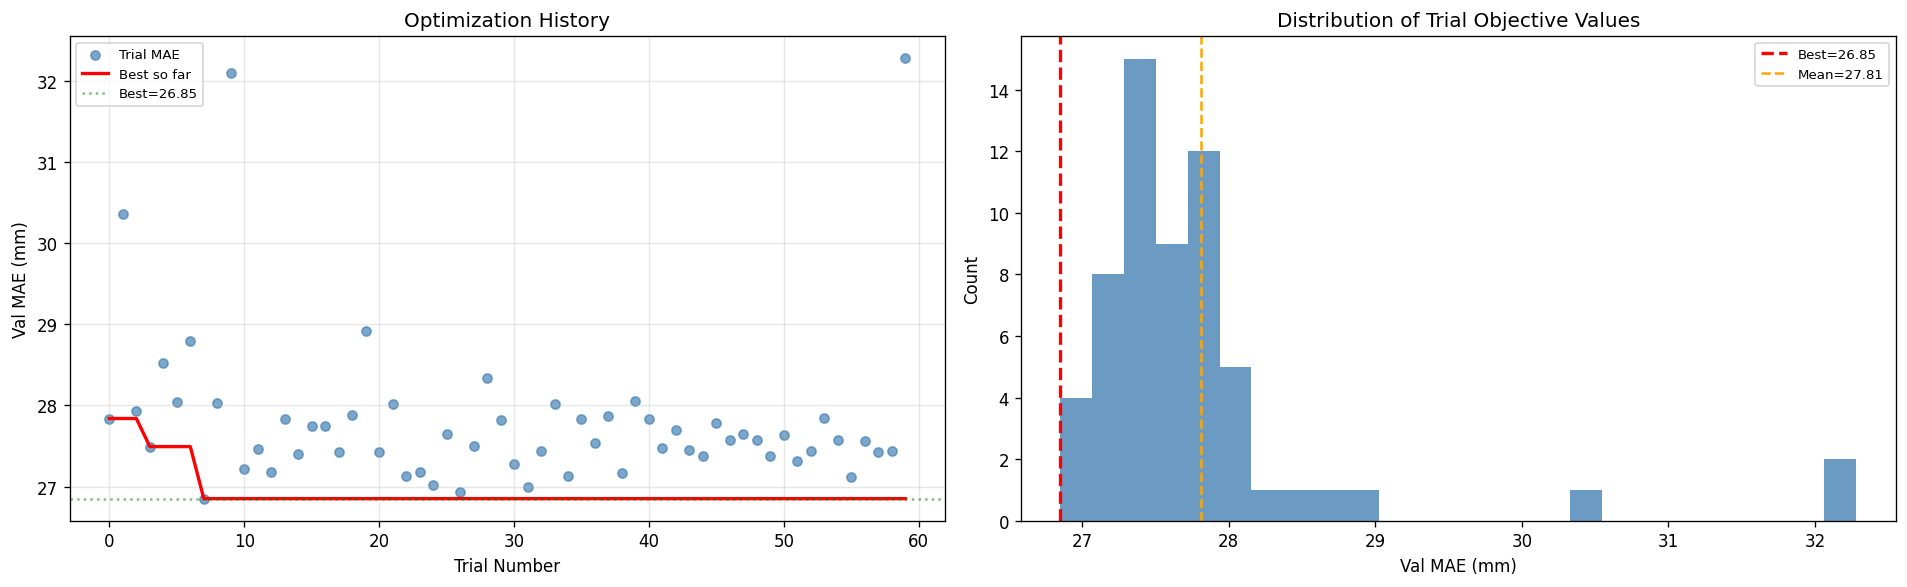


Trial statistics:
  Min: 26.850 mm
  Max: 32.282 mm
  Mean: 27.808 mm
  Std: 0.975 mm


In [4]:
# Optimization trajectory
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# All trial values
trial_nums = trials_df['number'].values
trial_vals = trials_df['value'].values
best_so_far = np.minimum.accumulate(trial_vals)

axes[0].scatter(trial_nums, trial_vals, c='steelblue', s=30, alpha=0.7, label='Trial MAE')
axes[0].plot(trial_nums, best_so_far, 'r-', lw=2, label='Best so far')
axes[0].axhline(trial_vals.min(), color='green', ls=':', alpha=0.5, label=f'Best={trial_vals.min():.2f}')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Val MAE (mm)')
axes[0].set_title('Optimization History')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Distribution of trial values
axes[1].hist(trial_vals, bins=25, color='steelblue', alpha=0.8, edgecolor='none')
axes[1].axvline(trial_vals.min(), color='red', ls='--', lw=2, label=f'Best={trial_vals.min():.2f}')
axes[1].axvline(trial_vals.mean(), color='orange', ls='--', label=f'Mean={trial_vals.mean():.2f}')
axes[1].set_xlabel('Val MAE (mm)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Trial Objective Values')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nTrial statistics:')
print(f'  Min: {trial_vals.min():.3f} mm')
print(f'  Max: {trial_vals.max():.3f} mm')
print(f'  Mean: {trial_vals.mean():.3f} mm')
print(f'  Std: {trial_vals.std():.3f} mm')

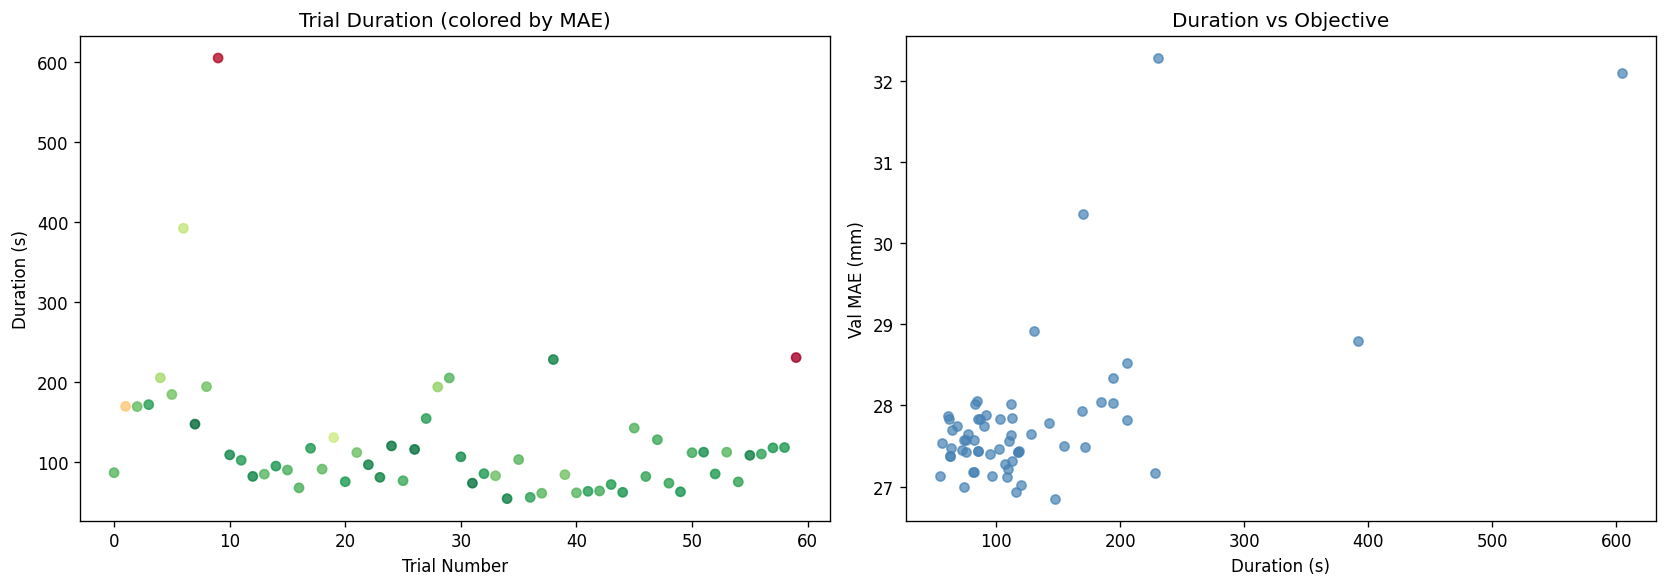

Mean duration: 124.4s, Total: 124.4 min


In [5]:
# Trial duration analysis
if 'duration' in trials_df.columns:
    durations = pd.to_timedelta(trials_df['duration']).dt.total_seconds()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(trial_nums, durations, c=trial_vals, cmap='RdYlGn_r', s=30, alpha=0.8)
    axes[0].set_xlabel('Trial Number')
    axes[0].set_ylabel('Duration (s)')
    axes[0].set_title('Trial Duration (colored by MAE)')
    
    axes[1].scatter(durations, trial_vals, c='steelblue', s=30, alpha=0.7)
    axes[1].set_xlabel('Duration (s)')
    axes[1].set_ylabel('Val MAE (mm)')
    axes[1].set_title('Duration vs Objective')
    
    plt.tight_layout()
    plt.show()
    print(f'Mean duration: {durations.mean():.1f}s, Total: {durations.sum()/60:.1f} min')

---
## 2. Hyperparameter Importance

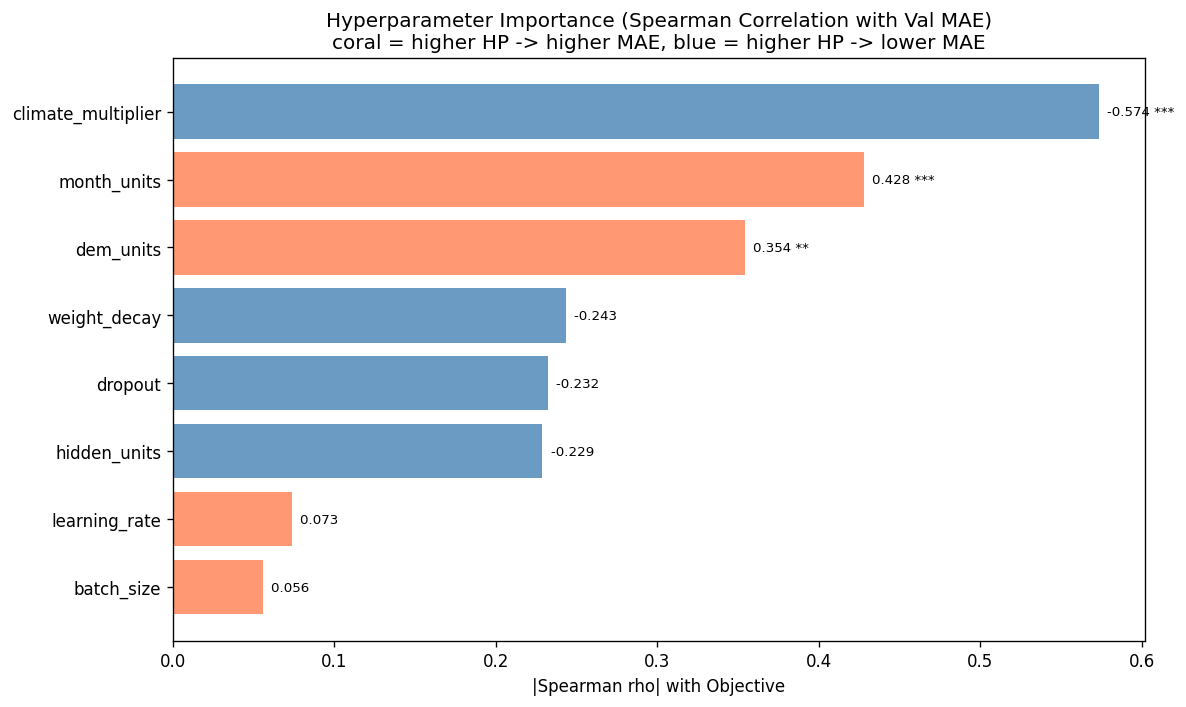

In [6]:
# Compute importance via correlation with objective
param_cols = [c for c in trials_df.columns if c.startswith('params_')]
param_names = [c.replace('params_', '') for c in param_cols]

# Spearman rank correlation as importance proxy
from scipy.stats import spearmanr
importances = {}
for col, name in zip(param_cols, param_names):
    rho, p = spearmanr(trials_df[col], trials_df['value'])
    importances[name] = {'rho': rho, 'abs_rho': abs(rho), 'p_value': p}

imp_df = pd.DataFrame(importances).T.sort_values('abs_rho', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['coral' if r > 0 else 'steelblue' for r in imp_df['rho']]
ax.barh(range(len(imp_df)), imp_df['abs_rho'], color=colors, alpha=0.8)
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df.index)
ax.set_xlabel('|Spearman rho| with Objective')
ax.set_title('Hyperparameter Importance (Spearman Correlation with Val MAE)\ncoral = higher HP -> higher MAE, blue = higher HP -> lower MAE')
for i, (_, row) in enumerate(imp_df.iterrows()):
    sig = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*' if row['p_value'] < 0.05 else ''
    ax.text(row['abs_rho'] + 0.005, i, f'{row["rho"]:.3f} {sig}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

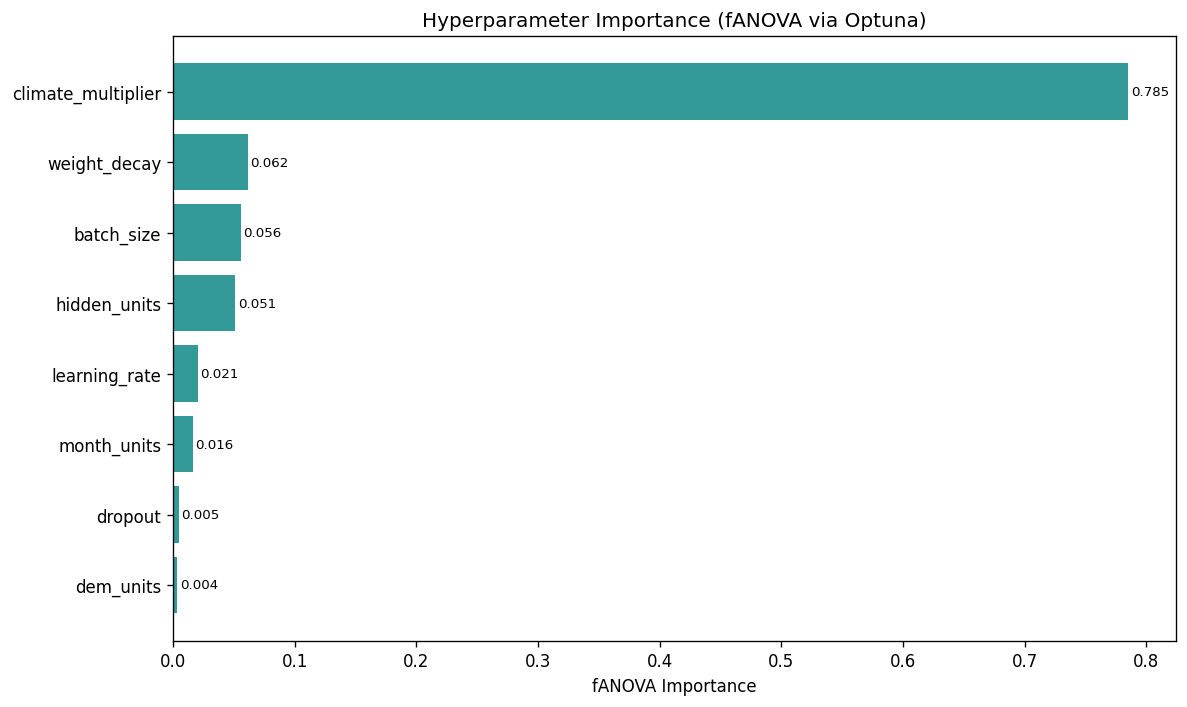

In [7]:
# Optuna's fANOVA importance (if available)
if HAS_OPTUNA:
    study = optuna.load_study(
        study_name='weekly_land',
        storage=f'sqlite:///{DB_PATH}'
    )
    try:
        importance = optuna.importance.get_param_importances(study)
        fig, ax = plt.subplots(figsize=(10, 6))
        sorted_imp = dict(sorted(importance.items(), key=lambda x: x[1]))
        ax.barh(list(sorted_imp.keys()), list(sorted_imp.values()), color='teal', alpha=0.8)
        ax.set_xlabel('fANOVA Importance')
        ax.set_title('Hyperparameter Importance (fANOVA via Optuna)')
        for i, (name, val) in enumerate(sorted_imp.items()):
            ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'fANOVA importance failed: {e}')
        print('Falling back to Spearman correlation (shown above)')

---
## 3. Parameter Marginal Effects (Slice Plots)

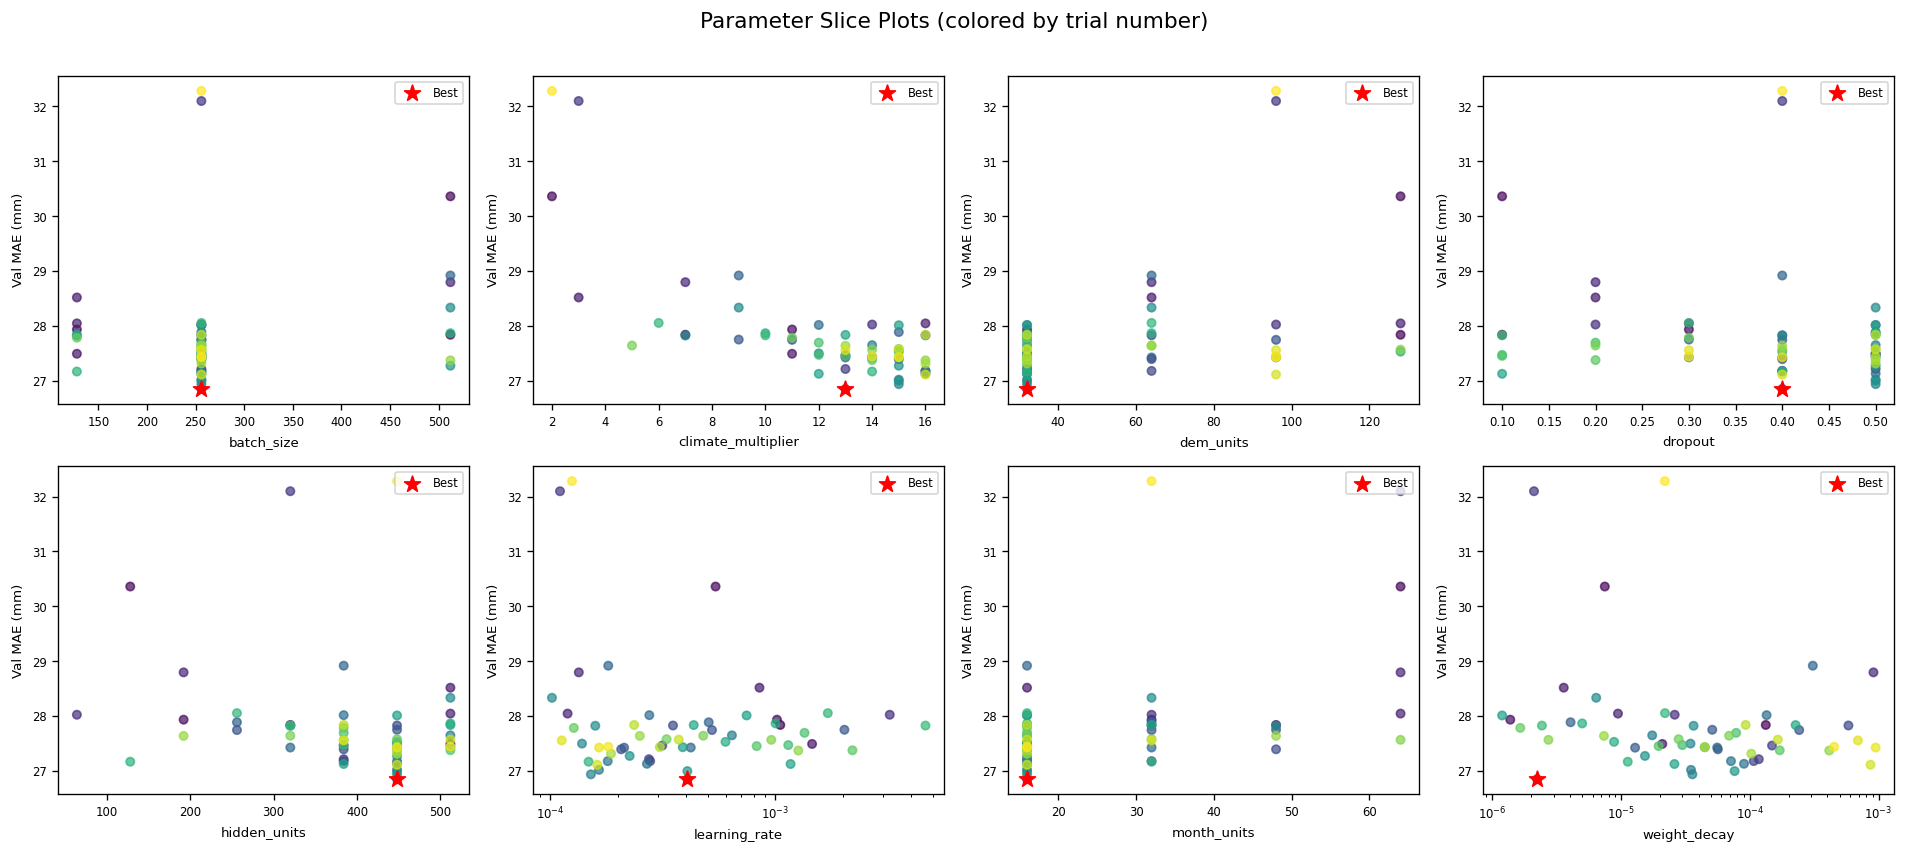

In [8]:
# Marginal effect of each parameter on objective (slice plots)
n_params = len(param_cols)
ncols = 4
nrows = int(np.ceil(n_params / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = axes.ravel()

for i, (col, name) in enumerate(zip(param_cols, param_names)):
    ax = axes[i]
    x = trials_df[col].values
    y = trials_df['value'].values
    
    # Color by trial number to show exploration
    sc = ax.scatter(x, y, c=trial_nums, cmap='viridis', s=25, alpha=0.7)
    
    # Mark best trial
    best_idx = np.argmin(y)
    ax.scatter(x[best_idx], y[best_idx], c='red', s=100, marker='*', zorder=5, label='Best')
    
    # Log scale for log-sampled parameters
    if name in ('learning_rate', 'weight_decay'):
        ax.set_xscale('log')
    
    ax.set_xlabel(name, fontsize=8)
    ax.set_ylabel('Val MAE (mm)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, loc='upper right')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Parameter Slice Plots (colored by trial number)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

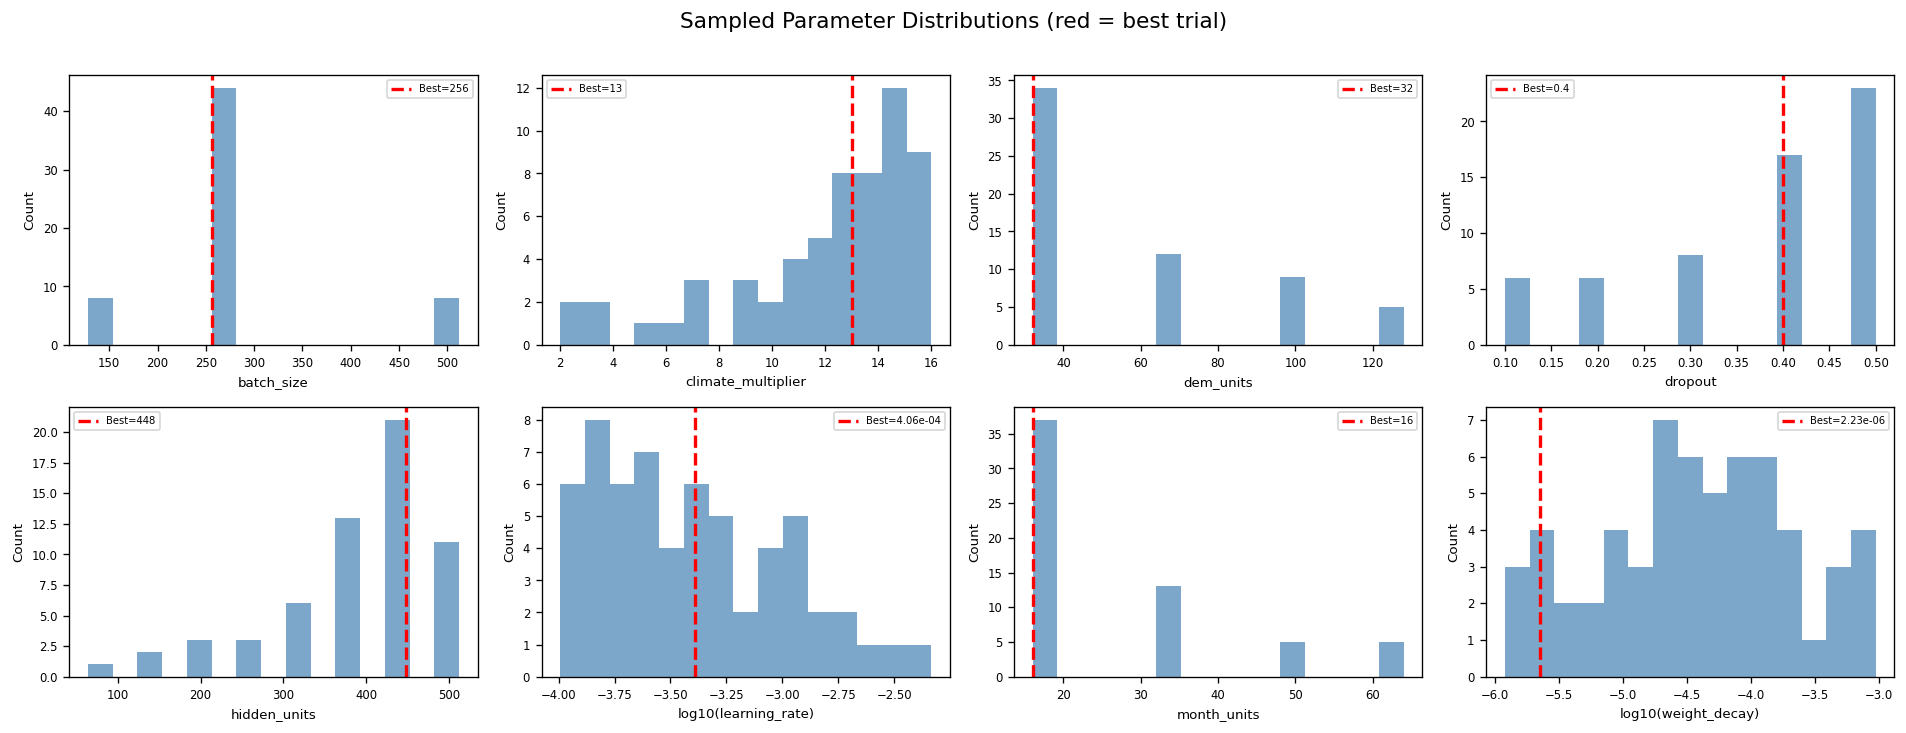

In [9]:
# Parameter distribution: sampled vs best
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.ravel()

for i, (col, name) in enumerate(zip(param_cols, param_names)):
    ax = axes[i]
    vals = trials_df[col].values
    best_val = vals[np.argmin(trial_vals)]
    
    if name in ('learning_rate', 'weight_decay'):
        ax.hist(np.log10(vals), bins=15, color='steelblue', alpha=0.7, edgecolor='none')
        ax.axvline(np.log10(best_val), color='red', ls='--', lw=2, label=f'Best={best_val:.2e}')
        ax.set_xlabel(f'log10({name})', fontsize=8)
    else:
        ax.hist(vals, bins=15, color='steelblue', alpha=0.7, edgecolor='none')
        ax.axvline(best_val, color='red', ls='--', lw=2, label=f'Best={best_val}')
        ax.set_xlabel(name, fontsize=8)
    
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Sampled Parameter Distributions (red = best trial)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Pairwise Parameter Interactions

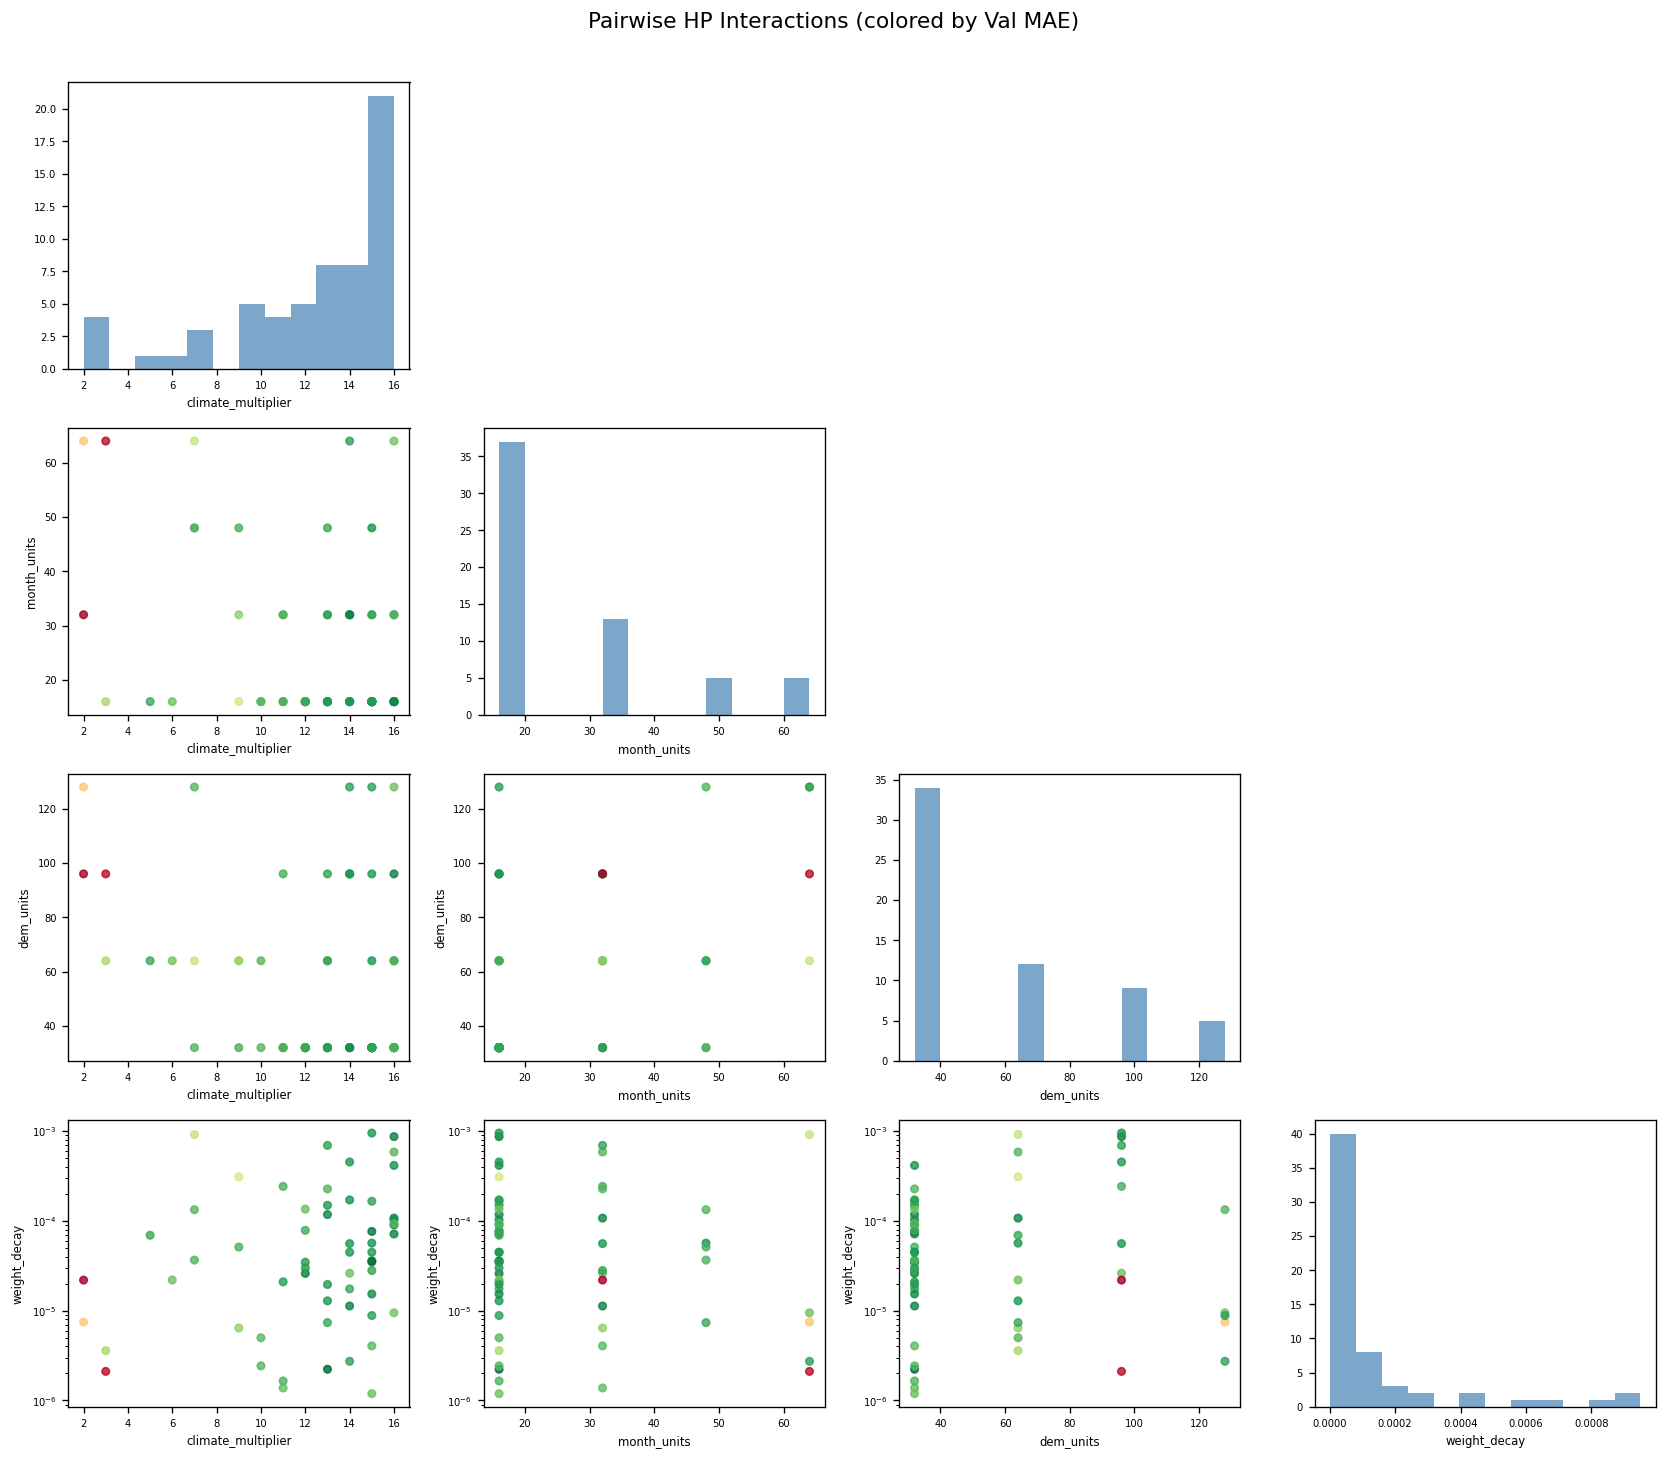

In [10]:
# Pairwise scatter for top-4 most important parameters
top_params = imp_df.index[-4:][::-1].tolist()  # top 4 by importance
top_cols = [f'params_{p}' for p in top_params]

n = len(top_params)
fig, axes = plt.subplots(n, n, figsize=(3.5 * n, 3 * n))
norm = Normalize(vmin=trial_vals.min(), vmax=trial_vals.max())

for i in range(n):
    for j in range(n):
        ax = axes[i][j]
        if i == j:
            ax.hist(trials_df[top_cols[i]], bins=12, color='steelblue', alpha=0.7, edgecolor='none')
            ax.set_xlabel(top_params[i], fontsize=7)
        elif i > j:
            sc = ax.scatter(
                trials_df[top_cols[j]], trials_df[top_cols[i]],
                c=trial_vals, cmap='RdYlGn_r', norm=norm, s=20, alpha=0.8
            )
            if top_params[j] in ('learning_rate', 'weight_decay'):
                ax.set_xscale('log')
            if top_params[i] in ('learning_rate', 'weight_decay'):
                ax.set_yscale('log')
            ax.set_xlabel(top_params[j], fontsize=7)
            ax.set_ylabel(top_params[i], fontsize=7)
        else:
            ax.set_visible(False)
        ax.tick_params(labelsize=6)

fig.suptitle('Pairwise HP Interactions (colored by Val MAE)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

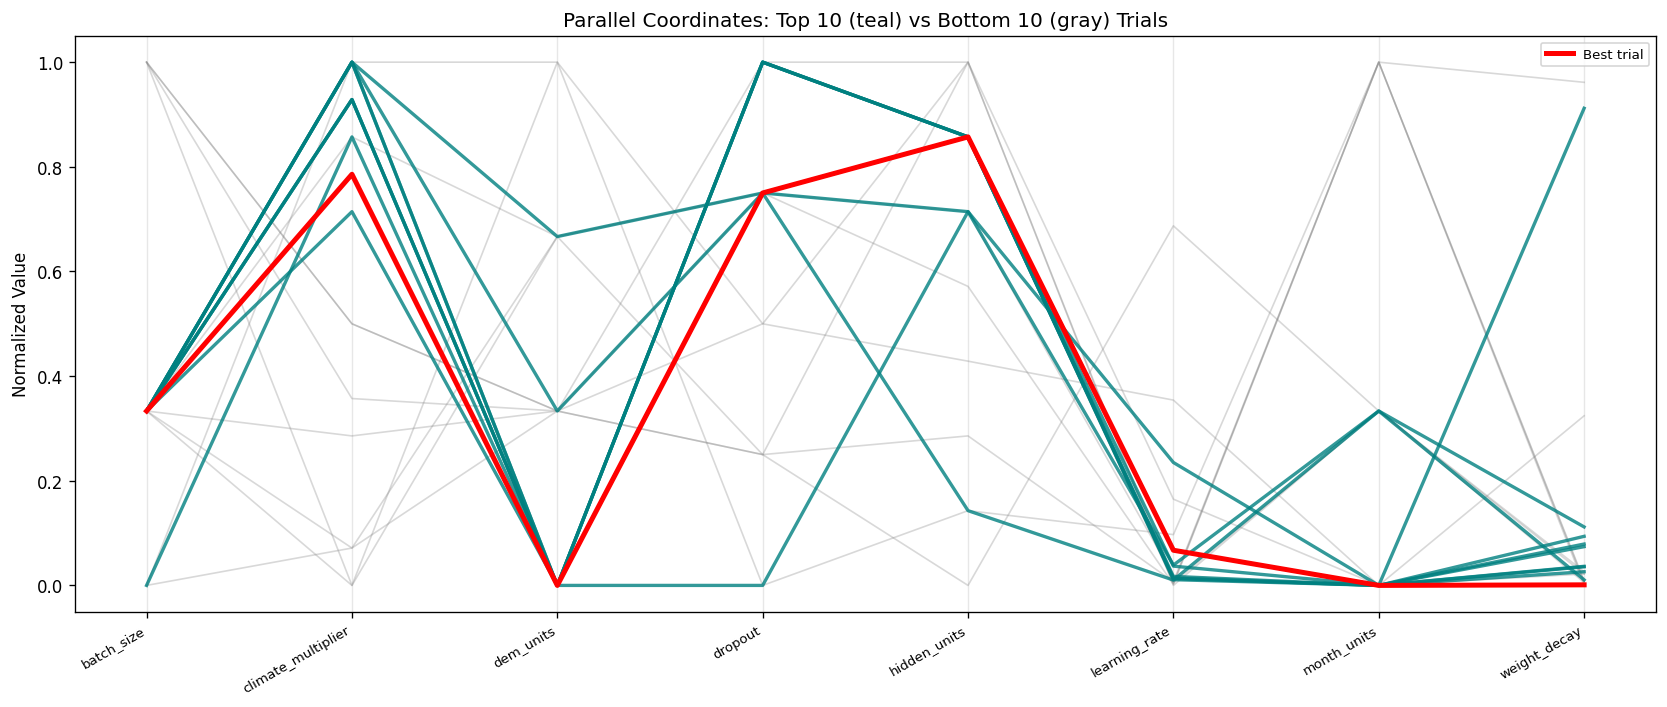

In [11]:
# Parallel coordinate plot of top-10 trials
top10 = trials_df.nsmallest(10, 'value')
bottom10 = trials_df.nlargest(10, 'value')

fig, ax = plt.subplots(figsize=(14, 6))

# Normalize parameters to [0, 1] for parallel coordinates
param_min = trials_df[param_cols].min()
param_max = trials_df[param_cols].max()
param_range = param_max - param_min
param_range[param_range == 0] = 1

for _, row in bottom10.iterrows():
    normalized = (row[param_cols] - param_min) / param_range
    ax.plot(range(len(param_cols)), normalized.values, alpha=0.3, color='gray', lw=1)

for _, row in top10.iterrows():
    normalized = (row[param_cols] - param_min) / param_range
    ax.plot(range(len(param_cols)), normalized.values, alpha=0.8, color='teal', lw=2)

# Best trial
best_row = trials_df.loc[trials_df['value'].idxmin()]
best_norm = (best_row[param_cols] - param_min) / param_range
ax.plot(range(len(param_cols)), best_norm.values, color='red', lw=3, label='Best trial')

ax.set_xticks(range(len(param_cols)))
ax.set_xticklabels(param_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Normalized Value')
ax.set_title('Parallel Coordinates: Top 10 (teal) vs Bottom 10 (gray) Trials')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Optuna Study Details (from SQLite)

In [12]:
# Query study.db directly for additional information
conn = sqlite3.connect(str(DB_PATH))

# Study metadata
study_meta = pd.read_sql_query('SELECT * FROM studies', conn)
print('Studies in DB:')
print(study_meta)

# Trial count by state
trial_states = pd.read_sql_query(
    'SELECT state, COUNT(*) as count FROM trials GROUP BY state', conn
)
print('\nTrial states:')
print(trial_states)

Studies in DB:
   study_id   study_name
0         1  weekly_land

Trial states:
      state  count
0  COMPLETE     60


In [13]:
# Per-trial intermediate values (if any were stored)
try:
    intermediates = pd.read_sql_query(
        'SELECT trial_id, step, intermediate_value FROM trial_intermediate_values ORDER BY trial_id, step',
        conn
    )
    if len(intermediates) > 0:
        print(f'Found {len(intermediates)} intermediate values')
        # Plot intermediate curves
        fig, ax = plt.subplots(figsize=(12, 5))
        for tid in intermediates['trial_id'].unique():
            subset = intermediates[intermediates['trial_id'] == tid]
            ax.plot(subset['step'], subset['intermediate_value'], alpha=0.3)
        ax.set_xlabel('Step')
        ax.set_ylabel('Intermediate Value')
        ax.set_title('Trial Intermediate Values')
        plt.tight_layout()
        plt.show()
    else:
        print('No intermediate values stored (single-objective without pruning)')
except Exception:
    print('No intermediate values table found')

conn.close()

No intermediate values stored (single-objective without pruning)


---
## 6. Convergence Analysis

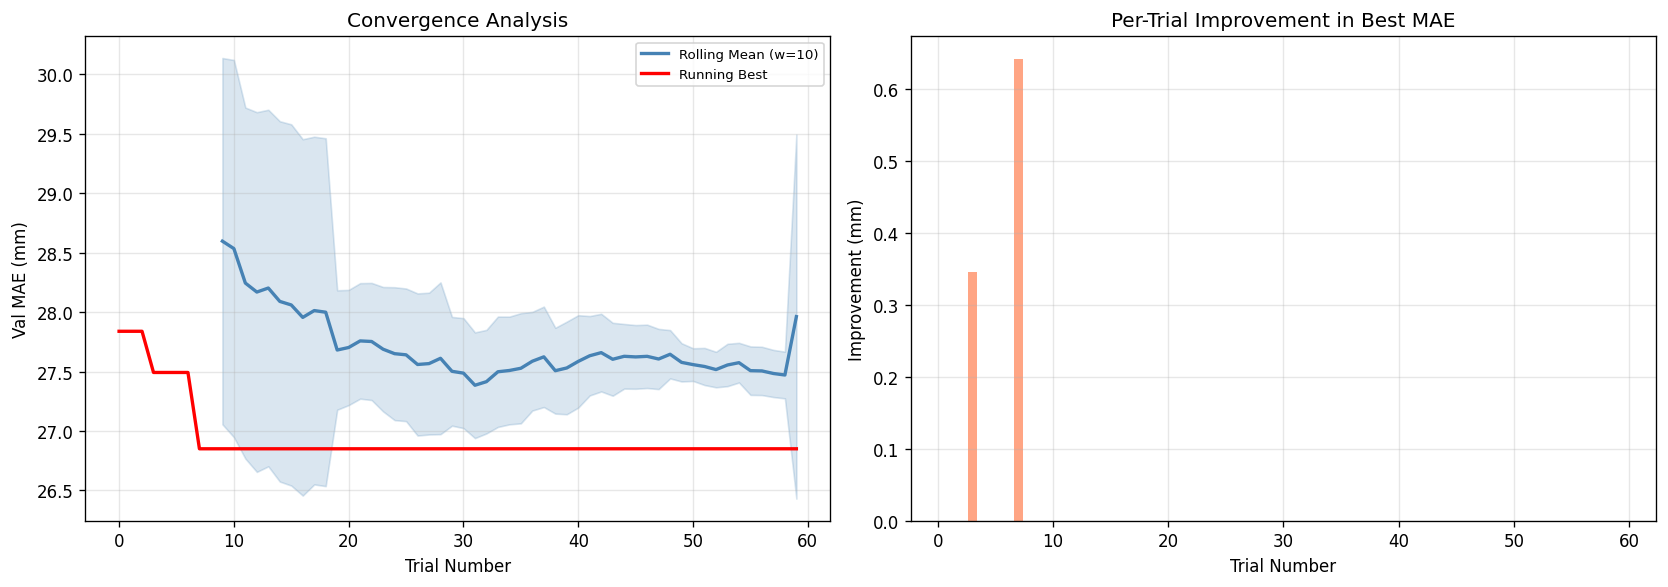

Trials that improved the best: 2/59
Last improvement at trial: 7


In [14]:
# Rolling statistics to assess convergence
window = 10
rolling_mean = pd.Series(trial_vals).rolling(window).mean()
rolling_std = pd.Series(trial_vals).rolling(window).std()
rolling_min = pd.Series(trial_vals).expanding().min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].fill_between(trial_nums, rolling_mean - rolling_std, rolling_mean + rolling_std,
                     alpha=0.2, color='steelblue')
axes[0].plot(trial_nums, rolling_mean, color='steelblue', lw=2, label=f'Rolling Mean (w={window})')
axes[0].plot(trial_nums, rolling_min, color='red', lw=2, label='Running Best')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Val MAE (mm)')
axes[0].set_title('Convergence Analysis')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Improvement rate
improvements = np.diff(np.minimum.accumulate(trial_vals))
axes[1].bar(trial_nums[1:], -improvements, color=['coral' if imp < 0 else 'gray' for imp in improvements],
            alpha=0.7)
axes[1].set_xlabel('Trial Number')
axes[1].set_ylabel('Improvement (mm)')
axes[1].set_title('Per-Trial Improvement in Best MAE')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Improvement summary
n_improvements = np.sum(improvements < 0)
print(f'Trials that improved the best: {n_improvements}/{len(improvements)}')
print(f'Last improvement at trial: {np.where(improvements < 0)[0][-1] + 1 if n_improvements > 0 else "N/A"}')

---
## 7. Train / Test Split & LOSO CV Visualization

In [15]:
# Load dataset and reproduce the strict spatiotemporal split logic from data.py
import sys
sys.path.insert(0, str(Path('..').resolve().parent))

# Import config to get the exact split constants
from LAND_AS import config

ds = np.load(DATASET_PATH, allow_pickle=True)
rainfall = ds['rainfall_mm_raw'].astype(float)
stations = ds['stations'].astype(str)
years = ds['years'].astype(int)
months = ds['months'].astype(int)

# Reproduce the strict spatiotemporal split logic from data.py
TRAIN_YEAR_END = config.TRAIN_YEAR_END
TEST_STATIONS = set(config.TEST_STATIONS)

names = sorted(set(stations))
roles = {n: 'test' if n in TEST_STATIONS else 'train' for n in names}

print(f'Station roles (strict spatiotemporal split):')
for role in ['train', 'test']:
    role_stations = sorted([n for n, r in roles.items() if r == role])
    print(f'  {role} ({len(role_stations)}): {role_stations}')

# Assign split labels with year constraint
role_arr = np.array([roles[s] for s in stations])
splits = {
    'train': (role_arr == 'train') & (years <= TRAIN_YEAR_END),
    'test': (role_arr == 'test') & (years > TRAIN_YEAR_END),
}

print(f'\nSplit sizes:')
for name, mask in splits.items():
    yr_range = years[mask]
    print(f'  {name}: {mask.sum()} samples ({100*mask.mean():.1f}%)')
    if len(yr_range) > 0:
        print(f'    years: {yr_range.min()}-{yr_range.max()}')

# Verify no overlap
train_stations = set(stations[splits['train']])
test_stations = set(stations[splits['test']])
train_years = set(years[splits['train']])
test_years = set(years[splits['test']])
print(f'\nStation overlap: {train_stations & test_stations}')
print(f'Year overlap: {train_years & test_years}')

Station roles (strict spatiotemporal split):
  train (21): [np.str_('aasufou80'), np.str_('aasufou90'), np.str_('airport5101'), np.str_('airport80'), np.str_('aoloafou'), np.str_('aua'), np.str_('aunuu'), np.str_('fagaitua'), np.str_('iliili'), np.str_('malaeimi'), np.str_('malaeimi_1691'), np.str_('maloata'), np.str_('masefau'), np.str_('matatula'), np.str_('mt_alava'), np.str_('pioa_afono'), np.str_('satala'), np.str_('siufaga_WRCC'), np.str_('toa_ridge_WRCC'), np.str_('vaipito2000'), np.str_('vaipito_res')]
  test (5): [np.str_('aasu_UH'), np.str_('afono_UH'), np.str_('aunuu_UH'), np.str_('poloa_UH'), np.str_('vaipito_UH')]

Split sizes:
  train: 6686 samples (77.7%)
    years: 1980-2016
  test: 1188 samples (13.8%)
    years: 2017-2024

Station overlap: set()
Year overlap: set()


In [16]:
# Per-station sample counts
unique_stations_sorted = sorted(names)
print(f'{"Station":<20} {"Role":>6} {"Samples":>8} {"Years":>12}')
print('-' * 50)
for s in unique_stations_sorted:
    mask = stations == s
    yr_range = f'{years[mask].min()}-{years[mask].max()}'
    print(f'{s:<20} {roles[s]:>6} {mask.sum():>8} {yr_range:>12}')

Station                Role  Samples        Years
--------------------------------------------------
aasu_UH                test      213    2017-2023
aasufou80             train     1002    1980-2000
aasufou90             train       48    1999-2000
afono_UH               test      351    2017-2024
airport5101           train      229    1999-2004
airport80             train      468    1980-1989
aoloafou              train      299    2000-2008
aua                   train      149    1993-1996
aunuu                 train      169    1997-2002
aunuu_UH               test       51    2022-2024
fagaitua              train      488    1997-2008
iliili                train       46    2000-2001
malaeimi              train       60    2003-2004
malaeimi_1691         train      842    1990-2008
maloata               train       60    2000-2001
masefau               train       73    2001-2004
matatula              train       56    2001-2002
mt_alava              train       98    2000-2002

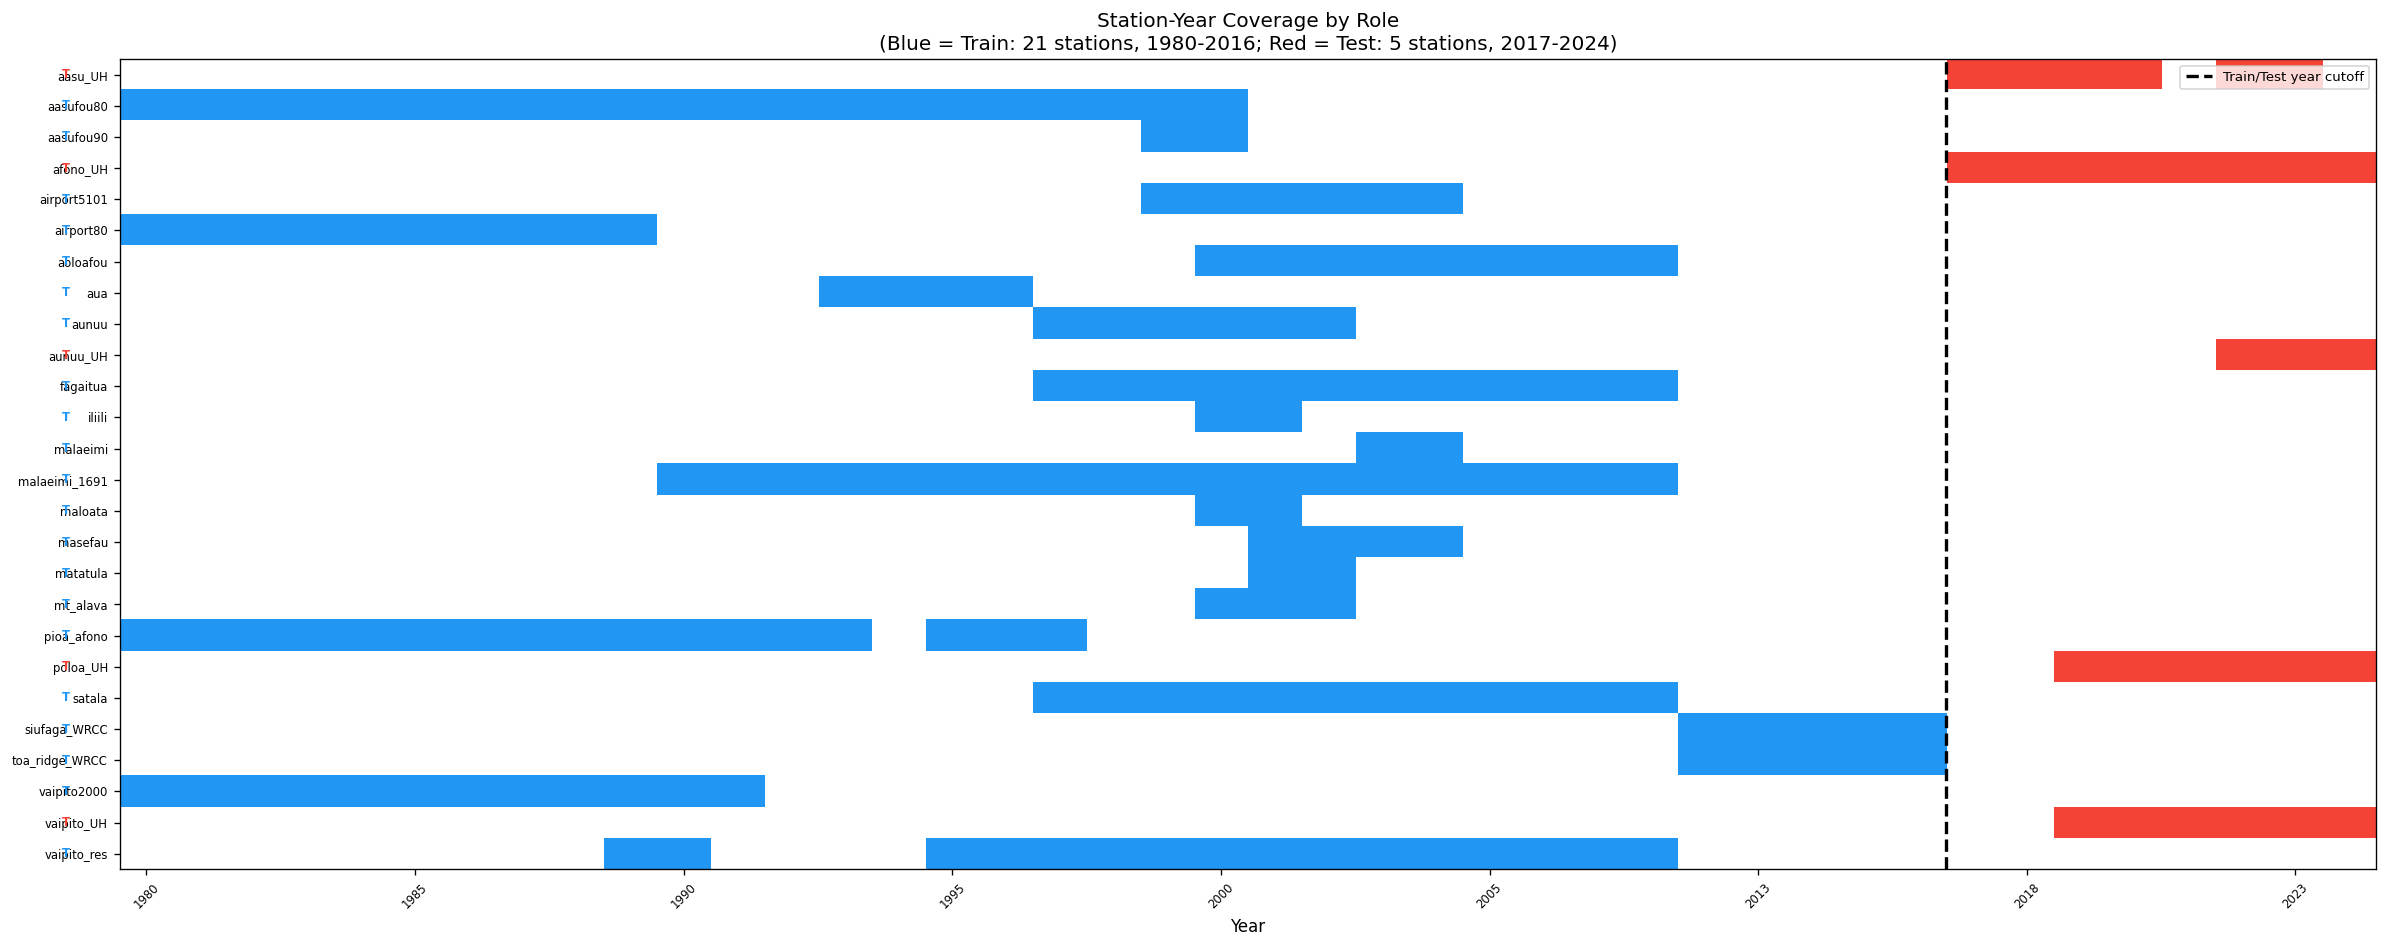


Train: 171 station-year cells
Test: 29 station-year cells


In [17]:
# Station-Year coverage heatmap colored by role
unique_years_all = np.sort(np.unique(years))

# Encode: 0=no data, 1=train (<=2016), 2=test (>=2017)
split_map = np.zeros((len(unique_stations_sorted), len(unique_years_all)))
for si, s in enumerate(unique_stations_sorted):
    for yi, y in enumerate(unique_years_all):
        mask = (stations == s) & (years == y)
        if mask.sum() > 0:
            if roles[s] == 'train' and y <= TRAIN_YEAR_END:
                split_map[si, yi] = 1
            elif roles[s] == 'test' and y > TRAIN_YEAR_END:
                split_map[si, yi] = 2

from matplotlib.colors import ListedColormap
cmap_split = ListedColormap(['white', '#2196F3', '#F44336'])

fig, ax = plt.subplots(figsize=(20, 8))
im = ax.imshow(split_map, aspect='auto', cmap=cmap_split, vmin=0, vmax=2, interpolation='nearest')
ax.set_yticks(range(len(unique_stations_sorted)))
ax.set_yticklabels(unique_stations_sorted, fontsize=7)

# Annotate station roles
for si, s in enumerate(unique_stations_sorted):
    role = roles[s]
    color = {'train': '#2196F3', 'test': '#F44336'}[role]
    ax.text(-1.5, si, role[0].upper(), ha='center', va='center', fontsize=7, fontweight='bold', color=color)

year_ticks = np.arange(0, len(unique_years_all), 5)
ax.set_xticks(year_ticks)
ax.set_xticklabels(unique_years_all[year_ticks], fontsize=7, rotation=45)
ax.set_xlabel('Year')
ax.set_title('Station-Year Coverage by Role\n(Blue = Train: 21 stations, 1980-2016; Red = Test: 5 stations, 2017-2024)')

# Year cutoff divider
cutoff_idx = np.searchsorted(unique_years_all, TRAIN_YEAR_END)
ax.axvline(cutoff_idx + 0.5, color='black', lw=2, ls='--', label='Train/Test year cutoff')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nTrain: {(split_map == 1).sum()} station-year cells')
print(f'Test: {(split_map == 2).sum()} station-year cells')

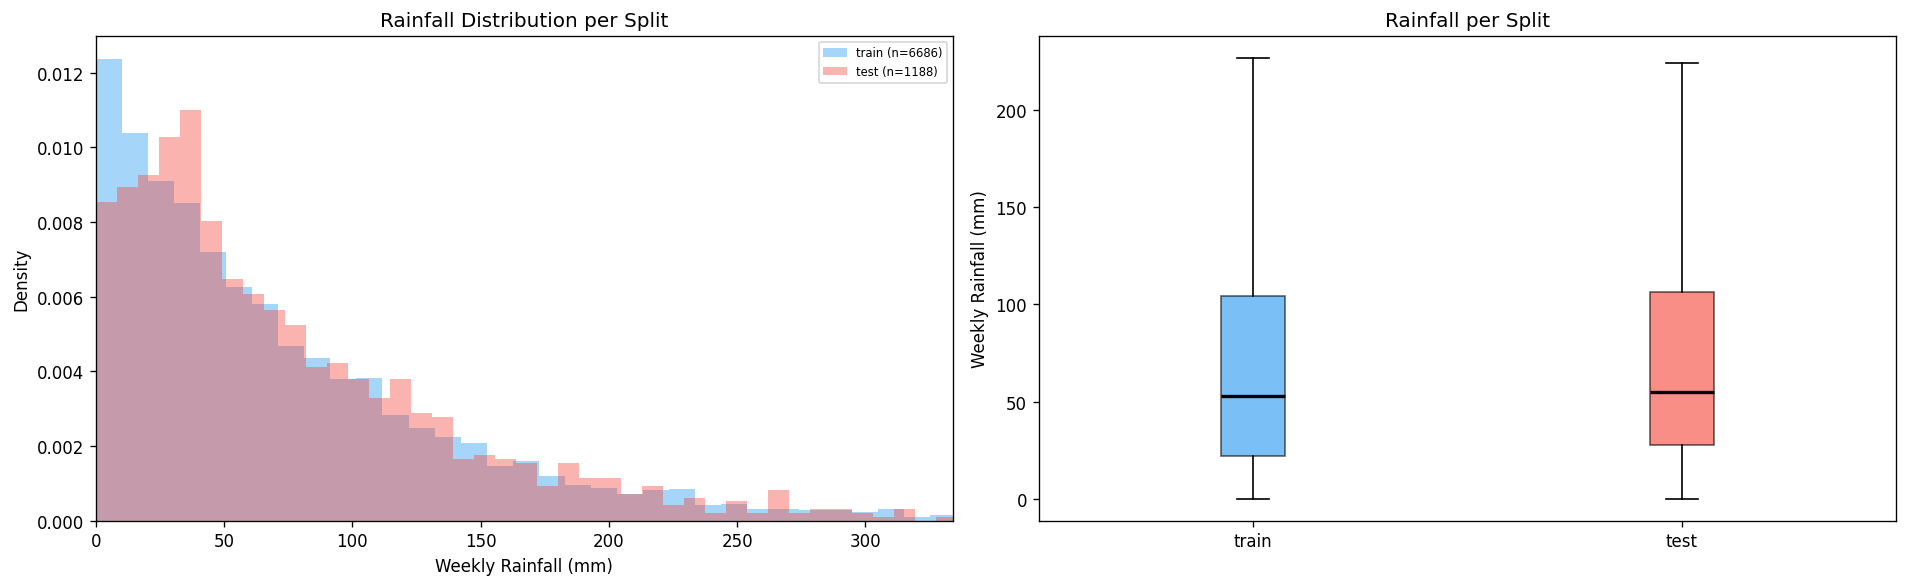

Split             N     Mean   Median      Std      P95
--------------------------------------------------
train          6686     75.0     53.1     75.4    222.5
test           1188     75.7     54.7     68.4    208.2


In [18]:
# Rainfall distribution per split
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

split_names_ordered = ['train', 'test']
split_colors_plot = ['#2196F3', '#F44336']

# Overlaid histograms
for name, color in zip(split_names_ordered, split_colors_plot):
    mask = splits[name]
    axes[0].hist(rainfall[mask], bins=80, alpha=0.4, color=color, label=f'{name} (n={mask.sum()})',
                 density=True, edgecolor='none')
axes[0].set_xlabel('Weekly Rainfall (mm)')
axes[0].set_ylabel('Density')
axes[0].set_title('Rainfall Distribution per Split')
axes[0].legend(fontsize=7)
axes[0].set_xlim(0, np.percentile(rainfall, 99))

# Boxplots
split_data = [rainfall[splits[n]] for n in split_names_ordered]
bp = axes[1].boxplot(split_data, labels=split_names_ordered, patch_artist=True, showfliers=False,
                     medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], split_colors_plot):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel('Weekly Rainfall (mm)')
axes[1].set_title('Rainfall per Split')

plt.tight_layout()
plt.show()

# Per-split summary statistics
print(f'{"Split":<10} {"N":>8} {"Mean":>8} {"Median":>8} {"Std":>8} {"P95":>8}')
print('-' * 50)
for name in split_names_ordered:
    mask = splits[name]
    r = rainfall[mask]
    print(f'{name:<10} {mask.sum():>8} {r.mean():>8.1f} {np.median(r):>8.1f} {r.std():>8.1f} {np.percentile(r, 95):>8.1f}')

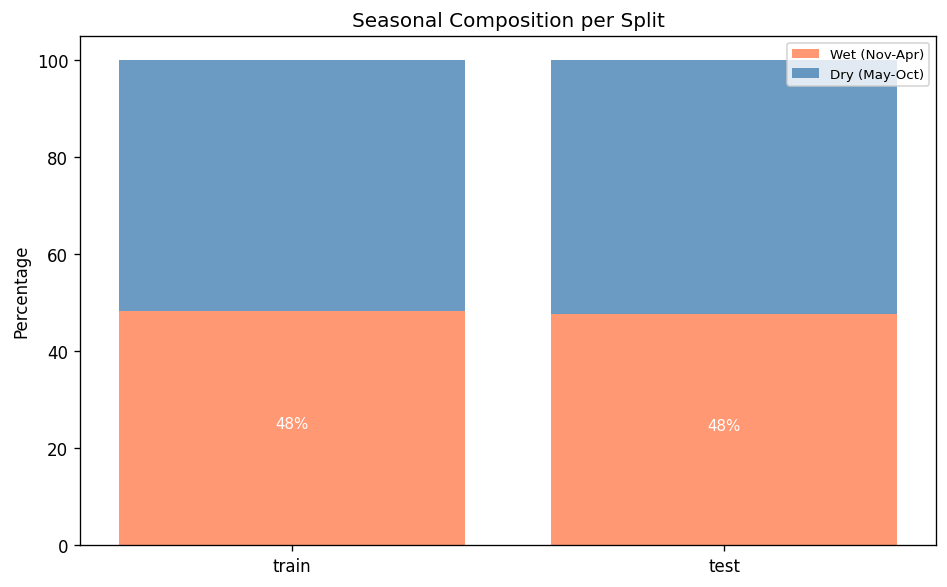

In [19]:
# Seasonal composition per split
is_wet = np.isin(months, [11, 12, 1, 2, 3, 4])

fig, ax = plt.subplots(figsize=(8, 5))
wet_fracs = []
dry_fracs = []
for name in split_names_ordered:
    mask = splits[name]
    wet_fracs.append(is_wet[mask].mean() * 100)
    dry_fracs.append((~is_wet[mask]).mean() * 100)

x = np.arange(len(split_names_ordered))
ax.bar(x, wet_fracs, color='coral', alpha=0.8, label='Wet (Nov-Apr)')
ax.bar(x, dry_fracs, bottom=wet_fracs, color='steelblue', alpha=0.8, label='Dry (May-Oct)')
ax.set_xticks(x)
ax.set_xticklabels(split_names_ordered, fontsize=10)
ax.set_ylabel('Percentage')
ax.set_title('Seasonal Composition per Split')
ax.legend(fontsize=8)
for i in range(len(split_names_ordered)):
    ax.text(i, wet_fracs[i] / 2, f'{wet_fracs[i]:.0f}%', ha='center', fontsize=9, color='white')
plt.tight_layout()
plt.show()

---
## 7. Train / Test Split & Spatial CV Fold Visualization

In [ ]:
# 3-fold spatial cross-validation fold visualization (matching tune.py)
# Reproduce the BALANCED k-fold spatial CV logic from data.py with mode='kfold':
# stations are sorted by sample count (descending) and dealt serpentine-style
# into 3 groups so each validation fold gets ~equal samples.
N_FOLDS = 3
train_stations_list = sorted(set(stations[splits['train']]))
station_counts = {s: int((splits['train'] & (stations == s)).sum()) for s in train_stations_list}
ordered = sorted(train_stations_list, key=lambda s: (-station_counts[s], s))
groups = [[] for _ in range(N_FOLDS)]
for position, station in enumerate(ordered):
    cycle, offset = divmod(position, N_FOLDS)
    group_index = offset if cycle % 2 == 0 else N_FOLDS - 1 - offset
    groups[group_index].append(station)

print(f'Tuning uses {N_FOLDS}-fold spatial CV over {len(train_stations_list)} train stations:')
print(f'  Train stations: {list(train_stations_list)}')
print(f'  Test stations: {sorted(TEST_STATIONS)}')
print(f'  Train years: 1980-{TRAIN_YEAR_END}')
print(f'  Test years: {TRAIN_YEAR_END+1}-2024')
print(f'  (folds are balanced by station sample count, serpentine dealing)\n')

print(f'{"Fold":>5} {"Held-Out Stations":<60} {"Train Samples":>14} {"Val Samples":>12}')
print('-' * 95)

fold_info = []
for i, group in enumerate(groups):
    group_names = [str(s) for s in group]
    val_mask = (splits['train']) & np.isin(stations, group_names)
    fold_train_mask = (splits['train']) & ~np.isin(stations, group_names)
    n_train = fold_train_mask.sum()
    n_val = val_mask.sum()
    fold_info.append({'stations': group_names, 'n_train': n_train, 'n_val': n_val})
    print(f'{i:>5} {str(group_names):<60} {n_train:>14} {n_val:>12}')

# Bar chart of fold sizes
fig, ax = plt.subplots(figsize=(10, 5))
fold_labels = [f'Fold {i}\n({len(f["stations"])} stns)' for i, f in enumerate(fold_info)]
fold_val_sizes = [f['n_val'] for f in fold_info]
fold_train_sizes = [f['n_train'] for f in fold_info]

x = np.arange(len(fold_info))
width = 0.35
ax.bar(x - width/2, fold_train_sizes, width, color='steelblue', alpha=0.8, label='Train')
ax.bar(x + width/2, fold_val_sizes, width, color='coral', alpha=0.8, label='Validation')
ax.set_xticks(x)
ax.set_xticklabels(fold_labels)
ax.set_ylabel('Samples')
ax.set_title(f'Tuning: {N_FOLDS}-Fold Spatial CV Train/Val Sizes\n(balanced serpentine assignment by station sample count)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Annotate values
for i, (tr, val) in enumerate(zip(fold_train_sizes, fold_val_sizes)):
    ax.text(i - width/2, tr + 50, str(tr), ha='center', fontsize=7)
    ax.text(i + width/2, val + 50, str(val), ha='center', fontsize=7)

plt.tight_layout()
plt.show()

NameError: name 'train_mask' is not defined

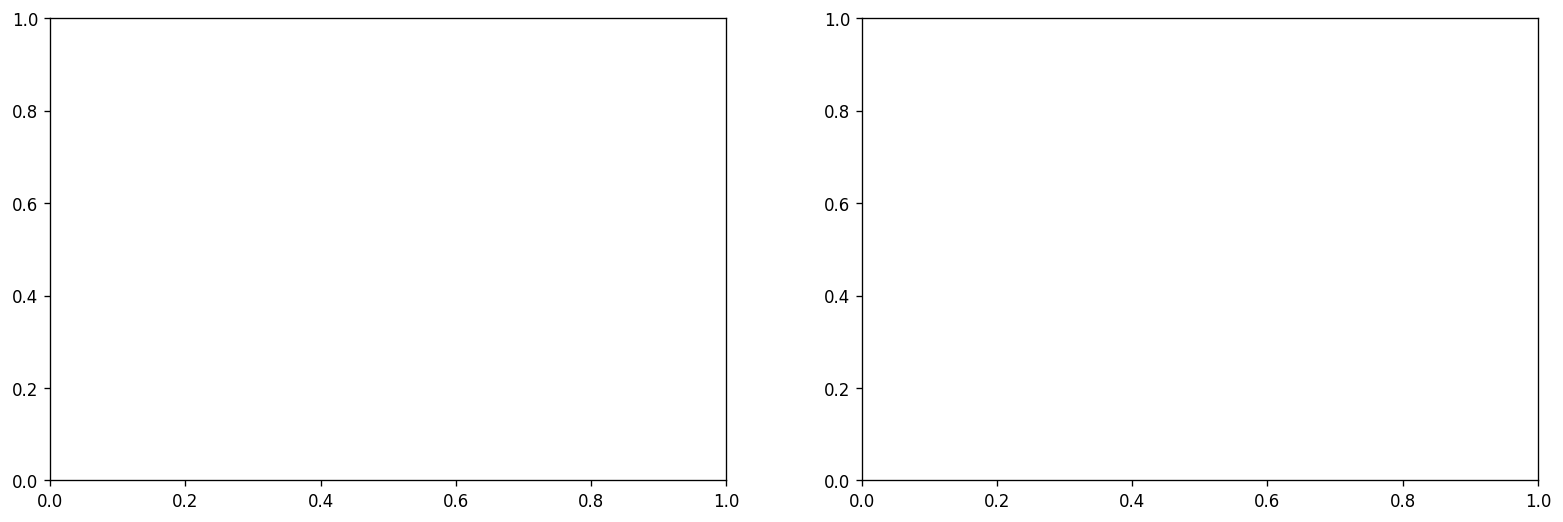

In [22]:
# 3-fold spatial CV: mean rainfall of held-out stations vs train mean per fold
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean rainfall of held-out validation stations per fold
fold_mean_rain = [rainfall[train_mask & np.isin(stations, f['stations'])].mean() for f in fold_info]
overall_train_mean = rainfall[train_mask].mean()

ax = axes[0]
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = ax.bar(range(len(fold_info)), fold_mean_rain, color=colors, alpha=0.8, edgecolor='black', lw=0.5)
ax.axhline(overall_train_mean, color='red', ls='--', lw=2, label=f'Train mean = {overall_train_mean:.1f} mm')
ax.set_xticks(range(len(fold_info)))
ax.set_xticklabels([f'Fold {i}' for i in range(len(fold_info))])
ax.set_ylabel('Mean Weekly Rainfall (mm)')
ax.set_title(f'Mean Rainfall of Held-Out Validation Stations per Fold\n({N_FOLDS}-fold spatial CV for tuning)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Number of stations per fold
n_stations_per_fold = [len(f['stations']) for f in fold_info]
ax2 = axes[1]
ax2.bar(range(len(fold_info)), n_stations_per_fold, color=colors, alpha=0.8, edgecolor='black', lw=0.5)
ax2.set_xticks(range(len(fold_info)))
ax2.set_xticklabels([f'Fold {i}' for i in range(len(fold_info))])
ax2.set_ylabel('# Stations')
ax2.set_title('Number of Stations in Each Validation Fold')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(n_stations_per_fold):
    ax2.text(i, v + 0.1, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 8. Best Trial Analysis

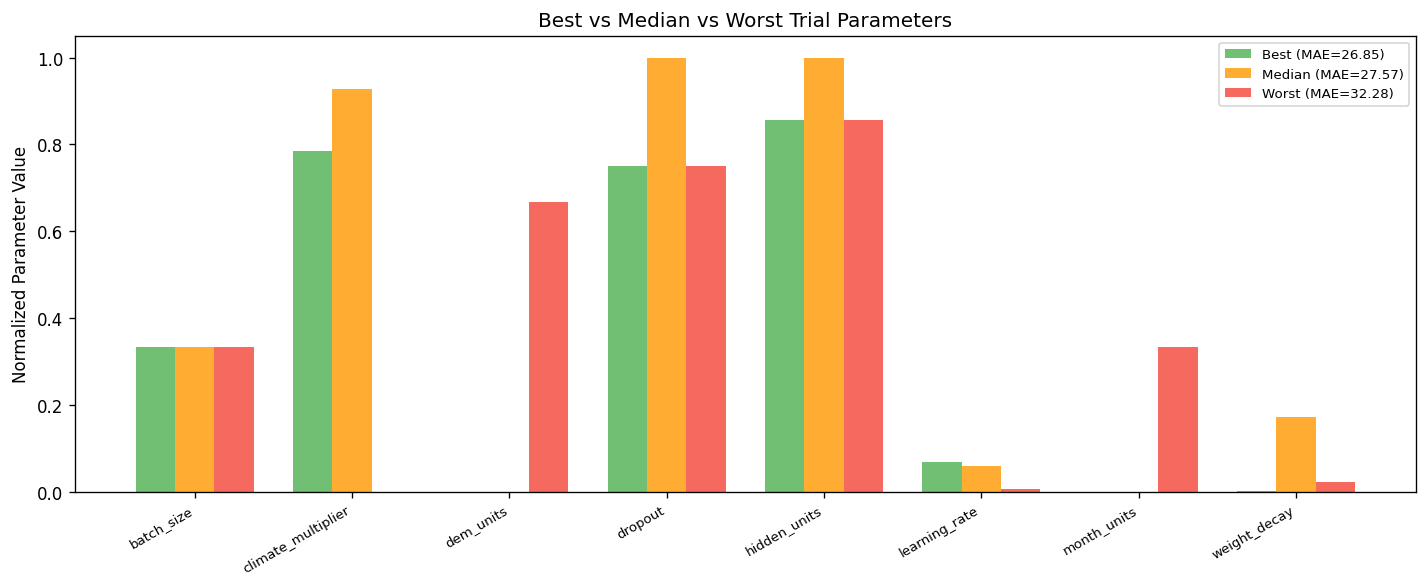

In [23]:
# Detailed comparison: best trial vs median trial vs worst trial
best_idx = trials_df['value'].idxmin()
median_idx = (trials_df['value'] - trials_df['value'].median()).abs().idxmin()
worst_idx = trials_df['value'].idxmax()

comparison_rows = trials_df.loc[[best_idx, median_idx, worst_idx]]
comparison_rows.index = ['Best', 'Median', 'Worst']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(param_names))
width = 0.25
colors_comp = ['#4CAF50', '#FF9800', '#F44336']

for i, (label, row) in enumerate(comparison_rows.iterrows()):
    # Normalize to [0,1] for comparability
    vals_norm = (row[param_cols].values - param_min.values) / param_range.values
    ax.bar(x + (i - 1) * width, vals_norm, width, label=f'{label} (MAE={row["value"]:.2f})',
           color=colors_comp[i], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(param_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Normalized Parameter Value')
ax.set_title('Best vs Median vs Worst Trial Parameters')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [24]:
# Summary table
print('\nComplete Trial Summary:')
display_cols = ['number', 'value'] + param_cols
for label, idx in [('Best', best_idx), ('Median', median_idx), ('Worst', worst_idx)]:
    row = trials_df.loc[idx]
    print(f'\n=== {label} Trial (#{int(row["number"])}) ===')
    print(f'  Val MAE: {row["value"]:.3f} mm')
    for col, name in zip(param_cols, param_names):
        print(f'  {name}: {row[col]}')


Complete Trial Summary:

=== Best Trial (#7) ===
  Val MAE: 26.850 mm
  batch_size: 256
  climate_multiplier: 13
  dem_units: 32
  dropout: 0.4
  hidden_units: 448
  learning_rate: 0.0004064644058668
  month_units: 16
  weight_decay: 2.226420430376969e-06

=== Median Trial (#54) ===
  Val MAE: 27.571 mm
  batch_size: 256
  climate_multiplier: 15
  dem_units: 32
  dropout: 0.5
  hidden_units: 512
  learning_rate: 0.0003718764964705
  month_units: 16
  weight_decay: 0.0001652219711386

=== Worst Trial (#59) ===
  Val MAE: 32.282 mm
  batch_size: 256
  climate_multiplier: 2
  dem_units: 96
  dropout: 0.4
  hidden_units: 448
  learning_rate: 0.0001248753521181
  month_units: 32
  weight_decay: 2.189860666884084e-05


---
## Summary

Key findings from the tuning study:
- Study explored hyperparameters with TPE sampling
- Train and test are **strictly spatiotemporally disjoint**:
  - Train: 21 stations, 1980–2016
  - Test: 5 stations (`aasu_UH`, `afono_UH`, `aunuu_UH`, `poloa_UH`, `vaipito_UH`), 2017–2024
  - No station overlap and no year overlap
- **Tuning** uses a 3-fold spatial CV over the 21 train stations (spatially disjoint, all years 1980–2016)
- **Final training** uses leave-one-station-out (LOSO) CV over the 21 train stations
- The test stations and test years are never seen during tuning or training